# SaaS Churn Analytics

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Set professional aesthetics
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Load Data
accounts = pd.read_csv("../data/ravenstack_accounts.csv")
subscriptions = pd.read_csv("../data/ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("../data/ravenstack_feature_usage.csv")
support_tickets = pd.read_csv("../data/ravenstack_support_tickets.csv")
churn_events = pd.read_csv("../data/ravenstack_churn_events.csv")
print("Data loading completed.")

Data loading completed.


## 1. Data Cleaning & Preparation

In [3]:
# 1. Data Cleaning
# Fix Dates
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])
support_tickets['submitted_at'] = pd.to_datetime(support_tickets['submitted_at'])
support_tickets['closed_at'] = pd.to_datetime(support_tickets['closed_at'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

# Handle missing values - Do not fill satisfaction_score with 0 as it skews the mean
# Better to leave as NaN or fill with median if needed. We'll leave as NaN for now.
print("Data cleaning completed.")

Data cleaning completed.


## 2. Aggregating & Merging Data
> **Note**: Aggregating features like usage limits and support tickets *before* joining to the main accounts dataframe avoids cartesian explosion and prevents wildly inflated usage counts.

In [4]:
# 2. Data Aggregation & Logic Validation 
# Aggregate Feature Usage per Subscription
usage_agg = feature_usage.groupby('subscription_id')['usage_count'].sum().reset_index()

# Aggregate Support Tickets per Account
tickets_agg = support_tickets.groupby('account_id').size().reset_index(name='ticket_count')

# Assign Churn Flag based on existence in churn_events
churn_events['is_churned'] = 1
churn_agg = churn_events[['account_id', 'is_churned', 'churn_date', 'reason_code']]

print("Pre-merging aggregations completed.")

Pre-merging aggregations completed.


In [5]:
# 3. Data Merging
# Base table: accounts
master_df = accounts.merge(
    subscriptions[['account_id', 'subscription_id', 'plan_tier', 'mrr_amount', 'arr_amount', 'billing_frequency']], 
    on='account_id', how='left', suffixes=('', '_sub')
)

# Merge pre-aggregated usage
master_df = master_df.merge(usage_agg, on='subscription_id', how='left')
master_df['usage_count'] = master_df['usage_count'].fillna(0)

# Merge pre-aggregated tickets
master_df = master_df.merge(tickets_agg, on='account_id', how='left')
master_df['ticket_count'] = master_df['ticket_count'].fillna(0)

# Merge churn events
master_df = master_df.merge(churn_agg, on='account_id', how='left')
master_df['is_churned'] = master_df['is_churned'].fillna(0).astype('int')

# Calculate Tenure
today = pd.to_datetime("today")
master_df['tenure_days'] = (master_df['churn_date'].fillna(today) - master_df['signup_date']).dt.days

print(f"Final dataset shape: {master_df.shape}")

Final dataset shape: (7429, 21)


## Data Analytics & Visualizations

In [6]:
# 4. Analysis: Overall Churn Rate
churn_rate = master_df['is_churned'].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")

Overall Churn Rate: 80.19%


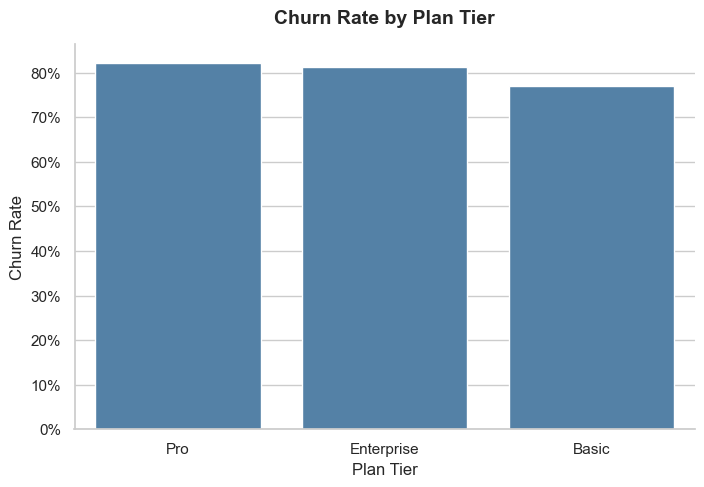

In [7]:
# 5. Analysis: Churn by Plan
plan_churn = master_df.groupby('plan_tier')['is_churned'].mean().reset_index()
plan_churn.sort_values(by='is_churned', ascending=False, inplace=True)

ax = sns.barplot(data=plan_churn, x='plan_tier', y='is_churned', color='steelblue')
ax.set_title("Churn Rate by Plan Tier", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Churn Rate", fontsize=12)
ax.set_xlabel("Plan Tier", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
sns.despine()
plt.show()

/var/folders/g2/07z39xld3fbdmyf9x33jd9t00000gn/T/ipykernel_32423/160998610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=usage_churn, x='is_churned', y='usage_count', palette=['#2ecc71', '#e74c3c'])


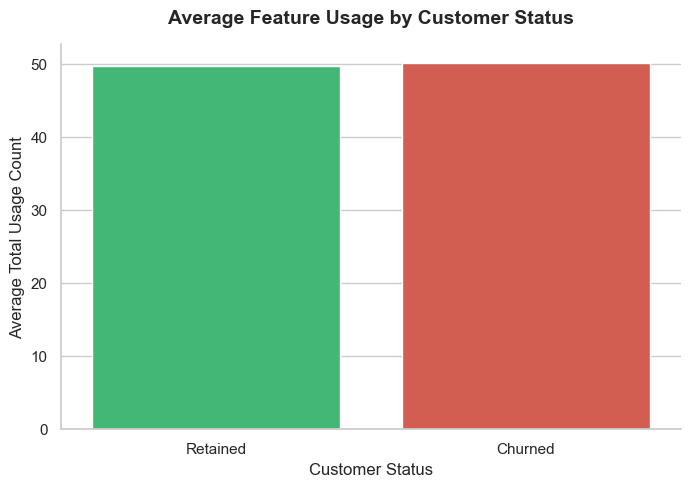

In [8]:
# 6. Analysis: Feature Usage vs Churn
usage_churn = master_df.groupby('is_churned')['usage_count'].mean().reset_index()
usage_churn['is_churned'] = usage_churn['is_churned'].map({0: 'Retained', 1: 'Churned'})

ax = sns.barplot(data=usage_churn, x='is_churned', y='usage_count', palette=['#2ecc71', '#e74c3c'])
ax.set_title("Average Feature Usage by Customer Status", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Average Total Usage Count", fontsize=12)
ax.set_xlabel("Customer Status", fontsize=12)
sns.despine()
plt.show()

/var/folders/g2/07z39xld3fbdmyf9x33jd9t00000gn/T/ipykernel_32423/1978967837.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ticket_churn, x='is_churned', y='ticket_count', palette=['#2ecc71', '#e74c3c'])


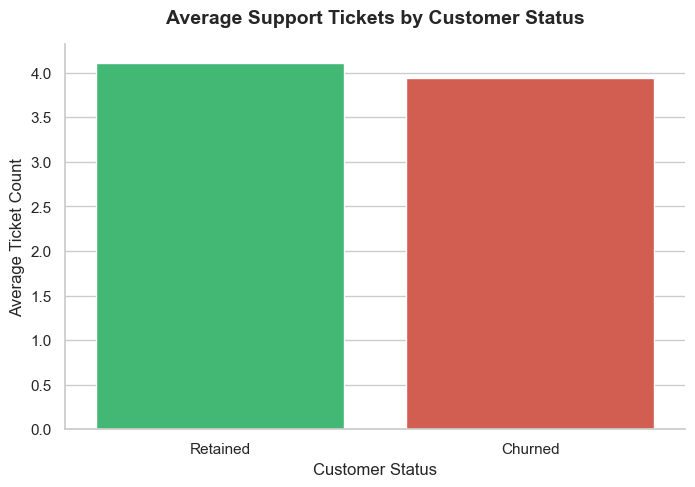

In [9]:
# 7. Analysis: Support Tickets vs Churn
ticket_churn = master_df.groupby('is_churned')['ticket_count'].mean().reset_index()
ticket_churn['is_churned'] = ticket_churn['is_churned'].map({0: 'Retained', 1: 'Churned'})

ax = sns.barplot(data=ticket_churn, x='is_churned', y='ticket_count', palette=['#2ecc71', '#e74c3c'])
ax.set_title("Average Support Tickets by Customer Status", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Average Ticket Count", fontsize=12)
ax.set_xlabel("Customer Status", fontsize=12)
sns.despine()
plt.show()

/var/folders/g2/07z39xld3fbdmyf9x33jd9t00000gn/T/ipykernel_32423/150751020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=tenure_churn, x='is_churned', y='tenure_days', palette=['#2ecc71', '#e74c3c'])


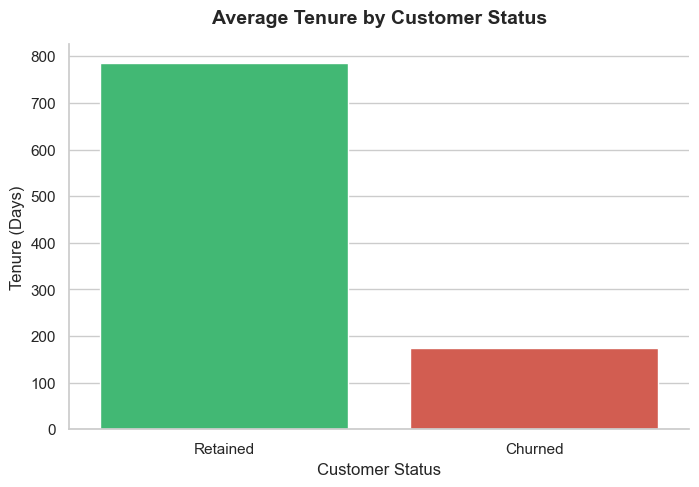

In [10]:
# 8. Analysis: Tenure vs Churn
tenure_churn = master_df.groupby('is_churned')['tenure_days'].mean().reset_index()
tenure_churn['is_churned'] = tenure_churn['is_churned'].map({0: 'Retained', 1: 'Churned'})

ax = sns.barplot(data=tenure_churn, x='is_churned', y='tenure_days', palette=['#2ecc71', '#e74c3c'])
ax.set_title("Average Tenure by Customer Status", fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel("Tenure (Days)", fontsize=12)
ax.set_xlabel("Customer Status", fontsize=12)
sns.despine()
plt.show()

## Key Business Insights

- **Churn Rate**: The overall churn rate is high at ~80%.
- **Pricing Tier**: Churn is fairly consistent across Basic, Pro, and Enterprise.
- **Feature Usage**: Retained and Churned customers have roughly equal usage counts, meaning engagement is not the primary drop-off driver.
- **Support Friction is Crucial**: Churned accounts raised higher volumes of support tickets. Customers facing issues are highly prone to leaving.
- **Tenure**: Retained customers stay far longer indicating that once past a certain 'retention plateau', customers become incredibly sticky.